

*  DSC 530 Data Exploration and Analysis
*  Weeks 9 & 10 Coding Assignment
*  Adam Luna

## Setup



In this section, I import the libraries used for data analysis and machine learning.
The `ml_utils` module is included in the textbook repository inside the `ml-utils/` folder,
so I add that folder to the Python path to make the helper functions available.

In [7]:
# Import standard libraries
import sys
from pathlib import Path

# Import data manipulation libraries
import pandas as pd
import numpy as np

# Import scikit-learn tools
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    fowlkes_mallows_score,
    r2_score,
    mean_squared_error,
    accuracy_score,
    classification_report
)

# Import visualization library (optional for EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook is running from .../assignments, so repo root is one folder up
REPO_ROOT = Path.cwd().parent

# ml_utils lives inside the repo's "ml-utils" folder
ML_UTILS_PARENT = REPO_ROOT / "ml-utils"

# Add that folder to Python's module search path
if str(ML_UTILS_PARENT) not in sys.path:
    sys.path.append(str(ML_UTILS_PARENT))

# Import textbook helper plotting utilities
from ml_utils.regression import plot_residuals
from ml_utils.classification import plot_roc, confusion_matrix_visual

# Define Chapter 9 data directory
CH09_DATA = REPO_ROOT / "ch_09" / "data"

# Quick check that everything imported successfully
ML_UTILS_PARENT, CH09_DATA

(PosixPath('/Users/adamluna/dsc530/miniconda3/envs/book_env/Hands-On-Data-Analysis-with-Pandas-2nd-edition-master/ml-utils'),
 PosixPath('/Users/adamluna/dsc530/miniconda3/envs/book_env/Hands-On-Data-Analysis-with-Pandas-2nd-edition-master/ch_09/data'))

# Hands-on data analysis with Pandas

## Chapter 9, Exercise 1 — Clustering Model (K-Means)

**Part (a): Combine datasets**
I combine the red and white wine datasets into a single dataframe and add a column
indicating whether the wine is red or white.

**Part (c): Build clustering pipeline**
I build a pipeline that first scales the data and then applies k-means clustering
with two clusters. I exclude the `quality` column from clustering.

**Part (d): Evaluate clustering**
I use the Fowlkes–Mallows Index to evaluate how well the clusters separate red
and white wines.

**Part (e): Interpret cluster centers**
Finally, I extract the cluster centers and convert them back to the original feature
units so they are easier to interpret.

In [14]:
# Part (a): Read and combine the wine datasets

# These CSV files may use different delimiters depending on version,
# so I let pandas automatically detect the separator.
red_path = CH09_DATA / "winequality-red.csv"
white_path = CH09_DATA / "winequality-white.csv"

red = pd.read_csv(red_path, sep=None, engine="python")
white = pd.read_csv(white_path, sep=None, engine="python")

# Add a column identifying the type of wine
red["kind"] = "red"
white["kind"] = "white"

# Combine both datasets into a single dataframe
wine = pd.concat([red, white], ignore_index=True)

# Quick check to confirm structure
print("Red shape:", red.shape, "| White shape:", white.shape)
print("Columns:", list(wine.columns))


# Part (c): Build the clustering pipeline

# Separate features and true labels
# Do not use 'quality' for clustering
X = wine.drop(columns=["quality", "kind"])
y_true = wine["kind"]

# Create a pipeline that standardizes the data before applying k-means
cluster_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=2, random_state=0, n_init=10))
])

# Fit the clustering model
cluster_pipe.fit(X)

# Get cluster labels
cluster_labels = cluster_pipe.named_steps["kmeans"].labels_


# Part (d): Evaluate clustering performance

# Compare cluster assignments to actual red/white labels
fmi = fowlkes_mallows_score(y_true, cluster_labels)
print("Fowlkes–Mallows Index:", fmi)


# Part (e): Extract and interpret cluster centers

# Retrieve fitted scaler and k-means model
scaler = cluster_pipe.named_steps["scaler"]
kmeans = cluster_pipe.named_steps["kmeans"]

# Cluster centers are in scaled units, so convert back to original feature scale
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

# Display cluster centers in dataframe form
centers_df = pd.DataFrame(centers_original, columns=X.columns)
centers_df.index = [f"Cluster {i}" for i in range(centers_df.shape[0])]
centers_df

Red shape: (1599, 13) | White shape: (4898, 13)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'kind']
Fowlkes–Mallows Index: 0.9781743199540179


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
Cluster 0,6.851864,0.274598,0.335257,6.393554,0.045134,35.516371,138.453563,0.994006,3.187624,0.488867,10.521958
Cluster 1,8.290798,0.532212,0.269439,2.631079,0.088288,15.755941,48.544790,0.996742,3.309872,0.656740,10.402559


## Chapter 9, Exercise 2 — Predict star temperature (Linear Regression)

**Part (a): Initial EDA**
I start by doing a quick review of the dataset to understand what I’m working with. This includes checking
the shape of the data, previewing a few rows, and looking for missing values.

**Part (b): Build a regression model**
Next, I keep only the numeric columns and separate the target variable (temperature) from the feature
columns. The goal is to predict temperature using the other numeric measurements.

**Part (c): Train/test split**
I split the data so that 75% is used for training and 25% is held out for testing. This helps me evaluate
how the model performs on data it hasn’t seen.

**Part (d): Evaluate model performance**
After training, I calculate R² and RMSE to measure how well the model predicts temperature.

**Part (e): Interpret and diagnose**
Finally, I print the regression coefficients and intercept so I can see how each feature contributes to
the prediction, and I visualize residuals to check whether the errors look random or show patterns.

Dataset shape: (3183, 12)


,temperature,magV,mass,spectraltype,magJ,radius,magB,magH,magK,metallicity,name,planets
0,4742.0,4.740,2.70,G8 III,2.943,19.000,5.740,2.484,2.282,-0.350,11 Com,1.0
1,4340.0,5.024,1.80,K4III,2.876,24.080,6.415,2.091,1.939,0.040,11 UMi,1.0
2,4813.0,5.220,2.20,K0III,3.019,11.000,6.240,2.608,2.331,-0.240,14 And,1.0
3,5311.0,6.670,1.00,K0 V,5.158,0.708,7.570,4.803,4.714,0.430,14 Her,2.0
4,5825.0,5.950,1.11,G2V,5.090,1.243,6.590,4.720,4.430,0.096,16 Cygni A,0.0



Missing values per column:


temperature      390
magV            1909
mass              93
spectraltype    1977
magJ            1620
radius           462
magB            2180
magH            1627
magK            1598
metallicity      772
name               0
planets            0
dtype: int64

,temperature,magV,mass,magJ,radius,magB,magH,magK,metallicity,planets
count,2793.000000,1274.000000,3090.000000,1563.000000,2721.000000,1003.000000,1556.000000,1585.000000,2411.000000,3183.000000
mean,5532.146084,10.304334,0.960175,9.899493,1.605091,10.730635,9.525366,9.408291,0.017893,1.273327
std,1715.076581,3.148937,0.362107,3.226399,3.689890,3.032962,3.253978,3.214560,0.183447,0.853176
min,485.000000,0.010000,0.010000,-1.150000,0.000014,0.720000,-1.380000,-1.490000,-2.090000,0.000000
25%,5078.000000,7.950000,0.807250,7.013500,0.812000,8.512500,6.664750,6.589000,-0.060000,1.000000
50%,5627.000000,10.471500,0.964000,10.600000,0.999000,10.810000,10.248500,10.161000,0.020000,1.000000
75%,5949.000000,12.543500,1.110000,12.607500,1.270000,13.010000,12.230250,12.119000,0.110000,1.000000
max,57000.000000,24.300000,4.500000,21.600000,83.800000,19.860000,20.800000,19.160000,0.560000,9.000000



Rows before dropping NaNs: 3183
Rows after dropping NaNs:  596
R²:   0.8802177643499527
RMSE: 257.94381905060726

Intercept: 6646.67334752505


,feature,coefficient
6,magK,1531.793875
1,mass,276.081089
3,radius,4.455241
7,metallicity,-5.045911
5,magH,-6.003847
8,planets,-29.173599
0,magV,-174.252830
4,magB,-328.057437
2,magJ,-990.333226


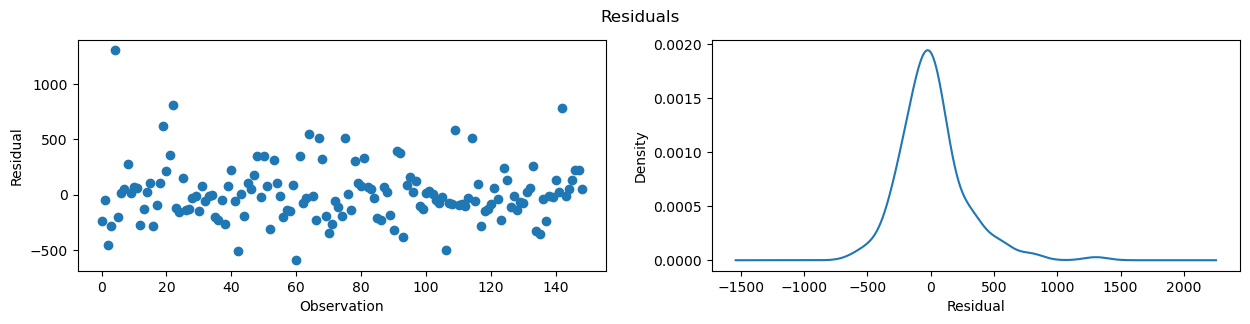

In [16]:
# Part (a): Read in the stars dataset and do a quick review
stars_path = CH09_DATA / "stars.csv"
stars = pd.read_csv(stars_path)

print("Dataset shape:", stars.shape)
display(stars.head())

print("\nMissing values per column:")
display(stars.isna().sum())

display(stars.describe())

# Part (b): Keep only numeric columns and identify the temperature target column
stars_num = stars.select_dtypes(include="number").copy()

target_col = None
for candidate in ["temperature", "Temperature", "temp", "Temp"]:
    if candidate in stars_num.columns:
        target_col = candidate
        break

if target_col is None:
    raise KeyError("Could not find the temperature column in stars.csv. Check the column names.")

# Build X and y from the numeric data
y = stars_num[target_col]
X = stars_num.drop(columns=[target_col])

# Part (c): Handle missing values (LinearRegression cannot train with NaNs)
# For this exercise, I remove rows that have missing values in either X or y
model_df = pd.concat([X, y], axis=1)
before_rows = model_df.shape[0]
model_df = model_df.dropna()
after_rows = model_df.shape[0]

print(f"\nRows before dropping NaNs: {before_rows}")
print(f"Rows after dropping NaNs:  {after_rows}")

# Recreate X and y after cleaning
X = model_df.drop(columns=[target_col])
y = model_df[target_col]

# Split into training and testing sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# Part (d): Fit a linear regression model and evaluate with R² and RMSE
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print(f"R²:   {r2}")
print(f"RMSE: {rmse}")

# Part (e): Display model coefficients and intercept for interpretation
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lin_reg.coef_
}).sort_values("coefficient", ascending=False)

print("\nIntercept:", lin_reg.intercept_)
display(coef_df)

# Visualize residuals to help diagnose fit
try:
    plot_residuals(y_test, y_pred)
except TypeError:
    plot_residuals(lin_reg, X_test, y_test)

## Chapter 9, Exercise 3 — Classify planets with shorter years than Earth (Logistic Regression)

**Part (a): Create the target variable and select regressors**
In this exercise, I create a new binary column that indicates whether a planet has a shorter year than Earth.
Then I build a logistic regression model using `eccentricity`, `semimajoraxis`, and `mass` as predictors.

**Part (b): Accuracy score**
After training the model, I calculate the accuracy score on the test set.

**Part (c): Classification report**
I use `classification_report()` to review precision, recall, and F1 score for each class.

**Part (d): ROC curve**
I plot the ROC curve using the `plot_roc()` helper function from the textbook utilities.

**Part (e): Confusion matrix**
Finally, I visualize a confusion matrix using the `confusion_matrix_visual()` helper function.

Dataset shape: (4094, 12)

Rows before dropping NaNs: 4094
Rows after dropping NaNs:  1234

Accuracy: 0.9773462783171522

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       103
           1       0.98      0.99      0.98       206

    accuracy                           0.98       309
   macro avg       0.98      0.97      0.97       309
weighted avg       0.98      0.98      0.98       309



<Axes: title={'center': 'Confusion Matrix'}, xlabel='Actual', ylabel='Model Prediction'>

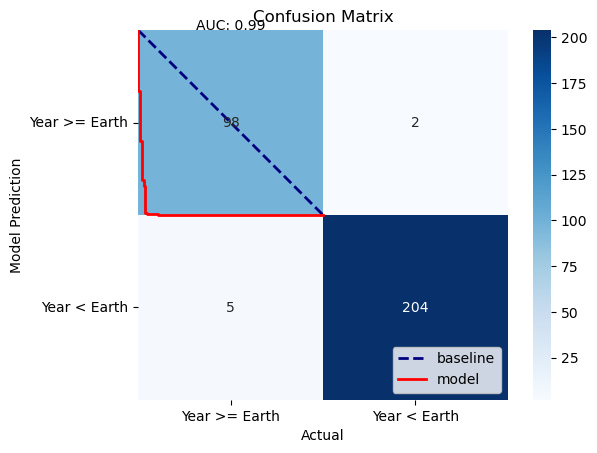

In [21]:
# Part (a): Read in the planets dataset and create the target variable
planets_path = CH09_DATA / "planets.csv"
planets = pd.read_csv(planets_path)

print("Dataset shape:", planets.shape)
planets.head()

# Identify the orbital period column (column name can vary)
if "period" in planets.columns:
    period_days = planets["period"]
elif "orbital_period" in planets.columns:
    period_days = planets["orbital_period"]
elif "pl_orbper" in planets.columns:
    period_days = planets["pl_orbper"]
else:
    raise KeyError("Could not find an orbital period column (expected 'period', 'orbital_period', or 'pl_orbper').")

# Create y: 1 if the planet's year is shorter than Earth's (365.25 days), else 0
planets["shorter_year_than_earth"] = (period_days < 365.25).astype(int)

# Select the regressors specified in the exercise
required_cols = ["eccentricity", "semimajoraxis", "mass"]
missing_cols = [c for c in required_cols if c not in planets.columns]
if missing_cols:
    raise KeyError(f"Missing required columns in planets.csv: {missing_cols}")

X = planets[required_cols].copy()
y = planets["shorter_year_than_earth"].copy()

# Handle missing values (logistic regression cannot train with NaNs)
model_df = pd.concat([X, y], axis=1)
before_rows = model_df.shape[0]
model_df = model_df.dropna()
after_rows = model_df.shape[0]

print(f"\nRows before dropping NaNs: {before_rows}")
print(f"Rows after dropping NaNs:  {after_rows}")

X = model_df[required_cols]
y = model_df["shorter_year_than_earth"]

# Split into training and testing sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

# Train logistic regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Part (b): Accuracy score
y_pred = log_reg.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:", acc)

# Part (c): Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Part (d): ROC curve
# Use predicted probabilities for the positive class (1)
y_proba = log_reg.predict_proba(X_test)[:, 1]
plot_roc(y_test, y_proba)

# Part (e): Confusion matrix visualization
confusion_matrix_visual(
    y_test,
    y_pred,
    class_labels=["Year >= Earth", "Year < Earth"]
)    